#.1 Training Dynamics কী?

Training dynamics বলতে বোঝায়—model training-এর সময় data কীভাবে model-এ দেওয়া হচ্ছে, loss কীভাবে পরিবর্তিত হচ্ছে এবং weights কীভাবে update হচ্ছে।

মূল পার্থক্য হলো প্রতি weight update-এ আমরা কতগুলো training sample ব্যবহার করছি:

Batch Gradient Descent: পুরো dataset
SGD: একটি sample
Mini-Batch: কয়েকটি sample

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
x=torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0]
])

y=torch.tensor([
    [2.0],
    [4.0],
    [6.0],
    [8.0],
    [10.0]
])

#model
model=nn.Linear(1,1)

#loss
criterion=nn.MSELoss()

#optimizer
optimizer=optim.SGD(model.parameters(),lr=0.01)

#3. Batch Gradient Descent

এখানে পুরো dataset ব্যবহার করে একবার weight update করা হয়।

In [3]:
model=nn.Linear(1,1)

criterion=nn.MSELoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)


for epoch in range(100):
  #forwars pass
  prediction=model(x)

  #calculate Loss
  loss=criterion(prediction,y)

  #clear old gradients
  optimizer.zero_grad()

  #Backpropagation
  loss.backward()

  #update weight
  optimizer.step()

  if epoch%10==0:
     print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 19.9646
Epoch 10, Loss: 0.0906
Epoch 20, Loss: 0.0008
Epoch 30, Loss: 0.0003
Epoch 40, Loss: 0.0003
Epoch 50, Loss: 0.0003
Epoch 60, Loss: 0.0003
Epoch 70, Loss: 0.0003
Epoch 80, Loss: 0.0002
Epoch 90, Loss: 0.0002


এখানে কী হচ্ছে?

ধরি dataset-এ 1000টি sample আছে।

Batch Gradient Descent-এ:


1000 samples

      ↓

Forward Pass

     ↓

Calculate Loss

     ↓

Backward Pass

     ↓

Update Weights

অর্থাৎ প্রতি epoch-এ একটি update।

সুবিধা
Gradient তুলনামূলকভাবে stable
Loss সাধারণত smooth ভাবে কমে
ছোট dataset-এর জন্য সহজ
অসুবিধা

Dataset অনেক বড় হলে পুরো dataset একসাথে memory-তে রাখতে হয় এবং প্রতিটি update-এর আগে অনেক computation করতে হয়।



#4. SGD — Stochastic Gradient Descent

SGD-তে একবারে মাত্র একটি sample নিয়ে weight update করা হয়।

In [22]:
model = nn.Linear(1, 1)

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):

    for i in range(len(x)):

        # One sample
        x_sample = x[i].unsqueeze(0)
        y_sample = y[i].unsqueeze(0)

        # Forward
        prediction = model(x_sample)

        # Loss
        loss = criterion(prediction, y_sample)

        # clear gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update
        optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 47.3648
Epoch 10, Loss: 0.0452
Epoch 20, Loss: 0.0315
Epoch 30, Loss: 0.0220
Epoch 40, Loss: 0.0153
Epoch 50, Loss: 0.0107
Epoch 60, Loss: 0.0074
Epoch 70, Loss: 0.0052
Epoch 80, Loss: 0.0036
Epoch 90, Loss: 0.0025


#6. Mini-Batch Gradient Descent

এটি সবচেয়ে বেশি ব্যবহৃত পদ্ধতিগুলোর একটি।

এখানে পুরো dataset না নিয়ে কিছু sample একসাথে ব্যবহার করা হয়।

যেমন:

Dataset = 1000 samples

Batch size = 32


তাহলে:

Batch 1 → 32 samples → Update

Batch 2 → 32 samples → Update

Batch 3 → 32 samples → Update

...

প্রতি epoch-এ প্রায়:

1000 / 32 ≈ 32 updates

#7. PyTorch DataLoader দিয়ে Mini-Batch

PyTorch-এ সাধারণত DataLoader ব্যবহার করা হয়।

In [29]:
from torch.utils.data import TensorDataset,DataLoader
dataset=TensorDataset(x,y)

dataloader=DataLoader(
    dataset,batch_size=2,shuffle=True
)

#এখন training:

In [35]:
model=nn.Linear(1,1)

criterion=nn.MSELoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)

for epoch in range(100):

    for x_batch,y_batch in dataloader:

        #Forward
        prediction=model(x_batch)

        #loss
        loss = criterion(prediction, y_batch)


        #clear gradients
        optimizer.zero_grad()

        #backward
        loss.backward()

        #update
        optimizer.step()

if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

#10. Training Loss Track করা

Training dynamics বুঝতে loss সংরক্ষণ করা গুরুত্বপূর্ণ।

In [36]:
loss_history = []

for epoch in range(100):

    for X_batch, y_batch in dataloader:

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    loss_history.append(loss.item())

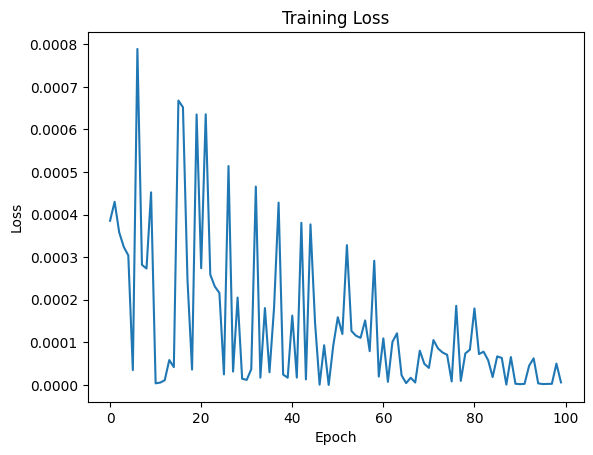

In [38]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

#11. Advanced: Batch Size Experiment

Training dynamics practically বোঝার জন্য একই model-এ বিভিন্ন batch size test করতে পারো।

In [39]:
batch_sizes = [1, 2, 4, 8, 16, 32]

In [40]:
for batch_size in batch_sizes:

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    model = nn.Linear(1, 1)

    criterion = nn.MSELoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.01
    )

    for epoch in range(100):

        for X_batch, y_batch in dataloader:

            prediction = model(X_batch)

            loss = criterion(
                prediction,
                y_batch
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

    print(
        f"Batch Size: {batch_size}, "
        f"Final Loss: {loss.item():.6f}"
    )

Batch Size: 1, Final Loss: 0.000036
Batch Size: 2, Final Loss: 0.035069
Batch Size: 4, Final Loss: 0.000005
Batch Size: 8, Final Loss: 0.018482
Batch Size: 16, Final Loss: 0.009516
Batch Size: 32, Final Loss: 0.055459


#2. আরও Advanced: Training Loop

বাস্তব project-এ training loop একটু structured করা ভালো।

In [41]:
def train_model(model, dataloader, criterion, optimizer, epochs):

    history = []

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for X_batch, y_batch in dataloader:

            # Forward
            output = model(X_batch)

            # Loss
            loss = criterion(output, y_batch)

            # Gradient reset
            optimizer.zero_grad()

            # Backward
            loss.backward()

            # Parameter update
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)

        history.append(avg_loss)

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:3d} | "
                f"Loss: {avg_loss:.6f}"
            )

    return history

In [42]:
model = nn.Linear(1, 1)

criterion = nn.MSELoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)

history = train_model(
    model,
    dataloader,
    criterion,
    optimizer,
    epochs=100
)

Epoch   0 | Loss: 85.093834
Epoch  10 | Loss: 0.438517
Epoch  20 | Loss: 0.052602
Epoch  30 | Loss: 0.047544
Epoch  40 | Loss: 0.044423
Epoch  50 | Loss: 0.041513
Epoch  60 | Loss: 0.038795
Epoch  70 | Loss: 0.036254
Epoch  80 | Loss: 0.033880
Epoch  90 | Loss: 0.031661


In [43]:
model = nn.Linear(1, 1)

criterion = nn.MSELoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)

history = train_model(
    model,
    dataloader,
    criterion,
    optimizer,
    epochs=100
)

Epoch   0 | Loss: 13.789663
Epoch  10 | Loss: 0.063464
Epoch  20 | Loss: 0.001389
Epoch  30 | Loss: 0.001036
Epoch  40 | Loss: 0.000967
Epoch  50 | Loss: 0.000904
Epoch  60 | Loss: 0.000845
Epoch  70 | Loss: 0.000789
Epoch  80 | Loss: 0.000738
Epoch  90 | Loss: 0.000689


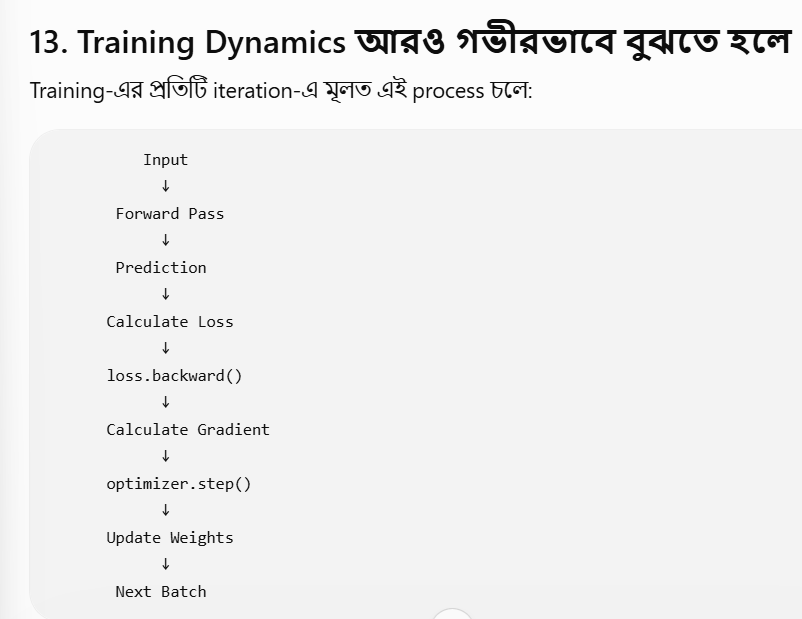

#14. Practical Deep Learning-এ কোনটি বেশি ব্যবহৃত?

বাস্তব PyTorch deep-learning project-এ সাধারণত Mini-Batch training ব্যবহার করা হয়।

উদাহরণ:

In [45]:
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [46]:
for X_batch, y_batch in train_loader:

    output = model(X_batch)

    loss = criterion(output, y_batch)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()